# Repaso final: Turismo internacional

Este repaso usa un contexto distinto al examen, pero practica los mismos patrones: recorrer datos, crear una función, filtrar, agrupar, ordenar, graficar e interpretar.

Trabaje con `turismo_internacional_repaso.csv` sin modificarlo. **Antes de iniciar, guarde una copia como `Apellido_Nombre_Repaso_Final.ipynb`.**

Distribución inequívoca: Parte 1, Parte 2, Parte 3, Parte 4, Parte 5 y cierre.

## Parte 1 — Preparación

**TODO 1.1 — Entrada, proceso y salida**

Escriba aquí una frase que identifique: (1) la entrada —el archivo y sus datos—, (2) el proceso —las operaciones de análisis— y (3) la salida —tablas, gráficos e interpretaciones.

**Respuesta:** La *entrada* es el archivo `turismo_internacional_repaso.csv`, con llegadas de turistas (en miles) por país y año (2012-2022) para 10 países de la región; el *proceso* consiste en convertir los datos a registros, filtrarlos y agruparlos con pandas (`groupby`, `pivot`, `nlargest`) para calcular totales, promedios y caídas porcentuales por país; y la *salida* son tablas resumen, un ranking de países líderes y tres gráficos (líneas, barras horizontales y barras agrupadas) con sus respectivas interpretaciones.

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

archivo = 'turismo_internacional_repaso.csv'
df = pd.read_csv(archivo)
df.head()

,pais,anio,llegadas_miles
0,Belize,2012,1028.0
1,Belize,2013,1022.0
2,Belize,2014,1289.0
3,Belize,2015,1299.0
4,Belize,2016,1391.0


In [18]:
pip install matplotlib


  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.3/9.3 MB 40.3 MB/s eta 0:00:00a 0:00:01
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 51.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.8/4.8 MB 56.7 MB/s eta 0:00:00
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)

[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Parte 2 — Python base: registros y función

1. Muestre `shape`, `dtypes` y una descripción breve de cada columna.
2. Convierta el DataFrame en una lista de diccionarios llamada `registros`.
3. Con un ciclo y una condición, cuente los registros cuya cantidad de llegadas es mayor a 3 000 miles.
4. Complete `resumen_pais`. Debe devolver un diccionario con país, cantidad de años, total y promedio de llegadas para el país solicitado. Si no existe, debe devolver `None`.

In [ ]:
# Escriba su solución aquí.
registros = df.to_dict(orient='records')
contador = 0
for registro in registros:
    #print(registro)
    if registro["llegadas_miles"] > 3000:
        contador += 1
# registros = ...
print(f"Registros con mas de 3000 mil visitante {contador}")

# contador = ...
def resumen_pais(registros, pais):
    # Recorra los registros y acumule solo los del país indicado.
    total = 0
    cantidad_anios = 0
    for registro in registros:
        if registro["pais"] == pais:
            total += registro["llegadas_miles"]
            cantidad_anios += 1

    if cantidad_anios == 0:
        return None

    promedio = total / cantidad_anios
    return {
        "pais": pais,
        "cantidad_anios": cantidad_anios,
        "total_llegadas": total,
        "promedio_llegadas": promedio
    }


# Pruebe la función con 'Costa Rica' y con un país inexistente.
print(resumen_pais(registros, "Mexico"))
print(resumen_pais(registros, "Desampakistan"))

Registros con mas de 3000 mil visitante 26
{'pais': 'Mexico', 'cantidad_anios': 9, 'total_llegadas': 762253.0, 'promedio_llegadas': 84694.77777777778}
None


## Parte 3 — Pandas: Análisis Comparativo y de Impacto

Con el nuevo conjunto de datos, podemos realizar un análisis regional más profundo.

1.  **Ranking de Líderes Regionales:**
    *   Calcula el **total de llegadas por país** para todo el período (2012-2022).
    *   Genera un ranking ordenado de mayor a menor para identificar los 3 países con más llegadas en la región.

2.  **Análisis de Impacto (COVID-19):**
    *   Crea un nuevo DataFrame que contenga únicamente los datos de 2019 y 2020.
    *   A partir de él, calcula la **caída porcentual** en el turismo para cada país. La fórmula es `((llegadas_2019 - llegadas_2020) / llegadas_2019) * 100`.
    *   Muestra una tabla con los resultados, ordenada de mayor a menor caída porcentual, para ver qué países fueron los más afectados.

In [34]:

ranking_paises = (
    df.groupby('pais')['llegadas_miles']
    .sum()
    .reset_index()
    .rename(columns={'llegadas_miles': 'total_llegadas'})
    .sort_values('total_llegadas', ascending=False)
)

top3 = ranking_paises.head(3)
print("Ranking de líderes regionales (total 2012-2022):")
print(ranking_paises)
print("\nTop 3 países con más llegadas:")
print(top3)


top5_registros = df[(df['anio'] >= 2019) & (df['llegadas_miles'] > 3000)].nlargest(5, 'llegadas_miles')
print("\nTop 5 registros individuales (2019 en adelante, con más de 3000 mil llegadas):")
print(top5_registros)


df_covid = df[(df['anio'] == 2019) | (df['anio'] == 2020)]

impacto = df_covid.pivot(index='pais', columns='anio', values='llegadas_miles')
impacto.columns = ['llegadas_2019', 'llegadas_2020']
impacto['caida_pct'] = ((impacto['llegadas_2019'] - impacto['llegadas_2020']) / impacto['llegadas_2019']) * 100
impacto = impacto.sort_values('caida_pct', ascending=False).reset_index()

print("\nCaída porcentual de turismo por país (2019 -> 2020):")
print(impacto)


top3_impacto = impacto.nlargest(3, 'caida_pct')
print("\nTop 3 países más afectados (mayor caída porcentual):")
print(top3_impacto)

Ranking de líderes regionales (total 2012-2022):
          pais  total_llegadas
6       Mexico        762253.0
1     Colombia         33974.0
9         Perú         32571.0
2   Costa Rica         25102.5
8       Panama         19670.0
5     Honduras         17614.0
3  El Salvador         17600.0
4    Guatemala         16197.0
7    Nicaragua         12247.0
0       Belize         11328.0

Top 3 países con más llegadas:
       pais  total_llegadas
6    Mexico        762253.0
1  Colombia         33974.0
9      Perú         32571.0

Top 5 registros individuales (2019 en adelante, con más de 3000 mil llegadas):
        pais  anio  llegadas_miles
52    Mexico  2019         97406.0
53    Mexico  2020         51128.0
82  Colombia  2022          4558.0
90      Perú  2019          4372.0
79  Colombia  2019          4332.0

Caída porcentual de turismo por país (2019 -> 2020):
          pais  llegadas_2019  llegadas_2020  caida_pct
0         Perú         4372.0          897.0  79.483074
1    Guate

## Parte 4 — Visualización Comparativa e Interpretación

Ahora, vamos a contar la historia de los datos con visualizaciones más ricas.

1.  **Gráfico de Líneas Comparativo:**
    *   Construye una gráfica de líneas que compare la evolución de llegadas para **todos los países** a lo largo de los años.
    *   **Interpretación:** Tu análisis debe mencionar: (1) La escala de México en comparación con los demás, (2) la tendencia general antes de 2020, y (3) el impacto visible de la pandemia en 2020 en todo el grupo.

2.  **Gráfico de Barras del Impacto (COVID-19):**
    *   Crea un **gráfico de barras horizontales** que muestre la **caída porcentual** por país que calculaste en la Parte 3.
    *   **Interpretación:** Explica qué países sufrieron el mayor y menor impacto relativo según la gráfica.

3.  **Gráfico de Barras de Recuperación:**
    *   Crea un **gráfico de barras agrupadas** que compare las llegadas de **2019 (pre-pandemia)** con las de **2022 (recuperación)** para cada país.
    *   **Interpretación:** Describe qué países parecen haberse recuperado más rápido y si alguno ha superado sus niveles pre-pandemia.

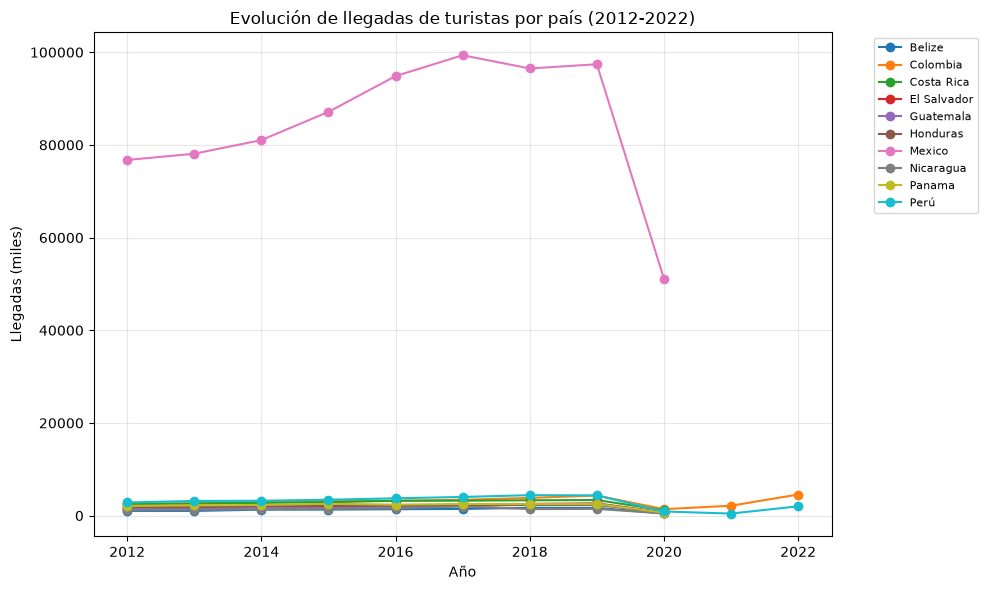

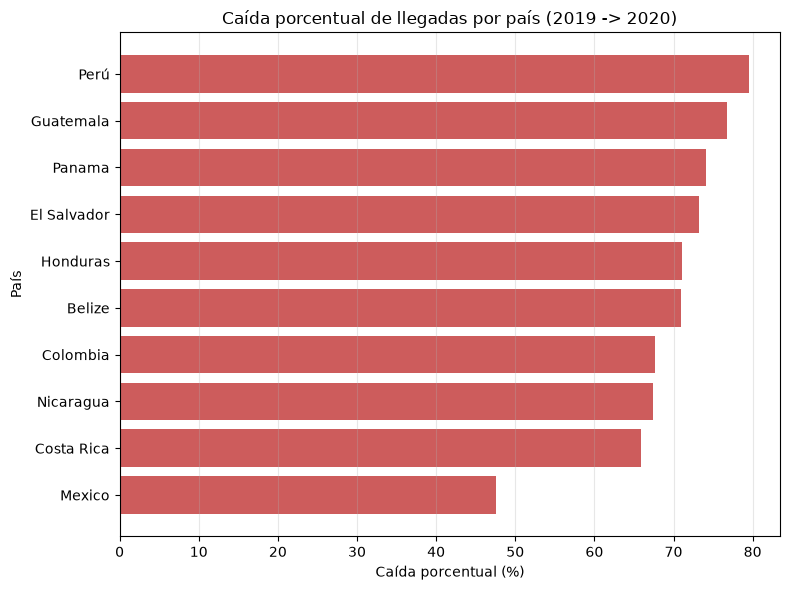

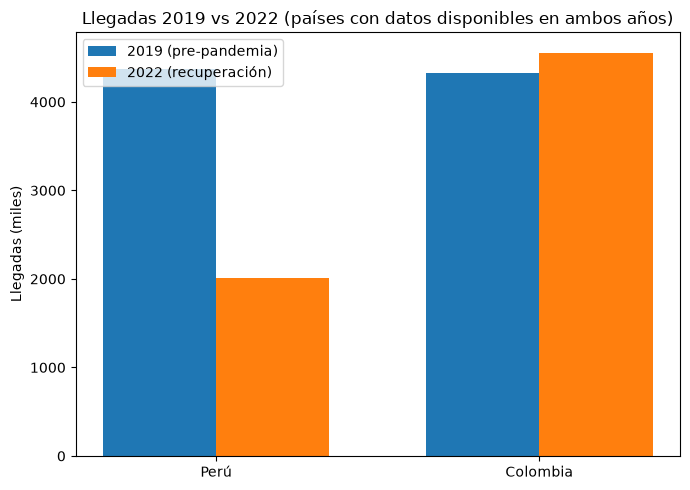

In [37]:
# Escriba aquí las tres gráficas.
# Use plt.show() al finalizar cada una e incluya una interpretación escrita.

# --- Gráfico 1: líneas comparativas de evolución por país ---
plt.figure(figsize=(10, 6))
for pais, grupo in df.groupby('pais'):
    grupo_ordenado = grupo.sort_values('anio')
    plt.plot(grupo_ordenado['anio'], grupo_ordenado['llegadas_miles'], marker='o', label=pais)

plt.title('Evolución de llegadas de turistas por país (2012-2022)')
plt.xlabel('Año')
plt.ylabel('Llegadas (miles)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



# --- Gráfico 2: barras horizontales del impacto COVID-19 (caída % 2019 -> 2020) ---
impacto_ordenado = impacto.sort_values('caida_pct')  # ascendente: el mayor impacto queda arriba en barh

plt.figure(figsize=(8, 6))
plt.barh(impacto_ordenado['pais'], impacto_ordenado['caida_pct'], color='indianred')
plt.title('Caída porcentual de llegadas por país (2019 -> 2020)')
plt.xlabel('Caída porcentual (%)')
plt.ylabel('País')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()



# --- Gráfico 3: barras agrupadas 2019 (pre-pandemia) vs 2022 (recuperación) ---
df_recuperacion = df[(df['anio'] == 2019) | (df['anio'] == 2022)]
recuperacion = df_recuperacion.pivot(index='pais', columns='anio', values='llegadas_miles')
recuperacion.columns = ['llegadas_2019', 'llegadas_2022']
recuperacion = recuperacion.dropna().sort_values('llegadas_2019', ascending=False)

x = range(len(recuperacion))
ancho = 0.35

plt.figure(figsize=(7, 5))
plt.bar([i - ancho / 2 for i in x], recuperacion['llegadas_2019'], width=ancho, label='2019 (pre-pandemia)')
plt.bar([i + ancho / 2 for i in x], recuperacion['llegadas_2022'], width=ancho, label='2022 (recuperación)')
plt.xticks(list(x), recuperacion.index)
plt.title('Llegadas 2019 vs 2022 (países con datos disponibles en ambos años)')
plt.ylabel('Llegadas (miles)')
plt.legend()
plt.tight_layout()
plt.show()



## Parte 5 — Mini-simulacro individual

Sin consultar soluciones, resuelva lo siguiente:

1. Convierta el DataFrame a una lista de diccionarios y cree una función que recorra los registros, use una condición y devuelva el total de llegadas de un país indicado; devuelva `None` si no existe.
2. Use un filtro compuesto para seleccionar registros de 2019 o posteriores con más de 3 000 miles de llegadas.
3. Cree un resumen con `groupby(...).agg(...)` y seleccione con `nlargest(5, 'llegadas_miles')` las cinco observaciones de mayor valor.
4. Elabore una gráfica de barras horizontales del ranking y redacte un hallazgo numérico verificable, una interpretación y una limitación del dataset.

**Autoevaluación:** ¿su respuesta incluye lista de diccionarios, ciclo, condición y función?, ¿sus filtros usan la columna correcta?, ¿aplicó `groupby(...).agg(...)` y `nlargest(5, ...)`?, ¿sus gráficos son legibles?, ¿sus afirmaciones tienen evidencia y una limitación?

19670.0
None

Registros desde 2019 con más de 3000 mil llegadas: 6
          pais  anio  llegadas_miles
16  Costa Rica  2019          3366.0
52      Mexico  2019         97406.0
53      Mexico  2020         51128.0
79    Colombia  2019          4332.0
82    Colombia  2022          4558.0
90        Perú  2019          4372.0

Top 5 países por total de llegadas:
         pais  llegadas_miles  anios
6      Mexico        762253.0      9
1    Colombia         33974.0     11
9        Perú         32571.0     11
2  Costa Rica         25102.5      9
8      Panama         19670.0      9


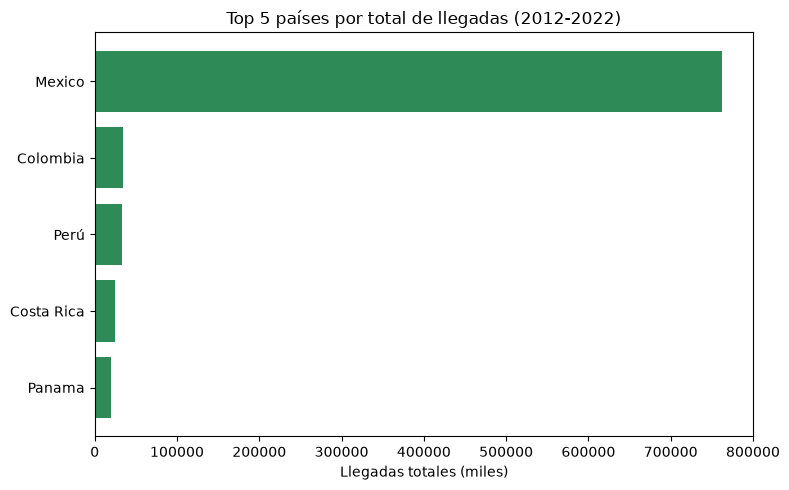

In [38]:
# Resuelva aquí el mini-simulacro.
# Incluya la función, el filtro compuesto, groupby(...).agg(...), nlargest(5, ...)
# y su interpretación con evidencia y limitación.

# --- 1. Lista de diccionarios + función con ciclo y condición ---
registros_simulacro = df.to_dict(orient='records')

def total_llegadas_pais(registros, pais):
    total = 0
    encontrado = False
    for registro in registros:
        if registro['pais'] == pais:
            total += registro['llegadas_miles']
            encontrado = True
    if not encontrado:
        return None
    return total

print(total_llegadas_pais(registros_simulacro, 'Panama'))
print(total_llegadas_pais(registros_simulacro, 'Atlantis'))

# --- 2. Filtro compuesto: año >= 2019 y llegadas > 3000 mil ---
filtro_compuesto = df[(df['anio'] >= 2019) & (df['llegadas_miles'] > 3000)]
print(f"\nRegistros desde 2019 con más de 3000 mil llegadas: {len(filtro_compuesto)}")
print(filtro_compuesto)

# --- 3. Resumen con groupby(...).agg(...) y nlargest(5, 'llegadas_miles') ---
resumen_groupby = df.groupby('pais').agg(
    llegadas_miles=('llegadas_miles', 'sum'),
    anios=('anio', 'count')
).reset_index()

top5_resumen = resumen_groupby.nlargest(5, 'llegadas_miles')
print("\nTop 5 países por total de llegadas:")
print(top5_resumen)

# --- 4. Gráfica de barras horizontales del ranking ---
plt.figure(figsize=(8, 5))
plt.barh(top5_resumen['pais'], top5_resumen['llegadas_miles'], color='seagreen')
plt.title('Top 5 países por total de llegadas (2012-2022)')
plt.xlabel('Llegadas totales (miles)')
plt.gca().invert_yaxis()  # país con más llegadas arriba
plt.tight_layout()
plt.show()



## Cierre y autoevaluación

Compare su trabajo con la lista de autoevaluación de la Parte 5. Entregue el notebook con su nombre, código ejecutado, tres gráficos, interpretaciones con evidencia y una limitación. La retroalimentación docente se realiza después del intento individual.